In [1]:
from fastai.vision.all import *

In [2]:
def label_func(f):
  name = f.name
  return name[0].isupper()

splitter = RandomSplitter(valid_pct=0.3)

pets = DataBlock(blocks=(ImageBlock, CategoryBlock),  # définition du TYPE d'entrée / sortie
                 get_items=get_image_files,           # définition du CHARGEMENT des entrées
                 get_y = label_func,                  # définition du CHARGEMENT des sorties
                 splitter=splitter)                   # définition de la SEPARATION des données (train, validation)

In [3]:
pets = DataBlock(blocks=(ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 get_y = label_func,
                 splitter=splitter,
                 item_tfms=Resize((200,200)))          # Changer la résolution les images pour obtenir une taille de 100x100 pour toutes

torch.Size([8, 3, 200, 200])


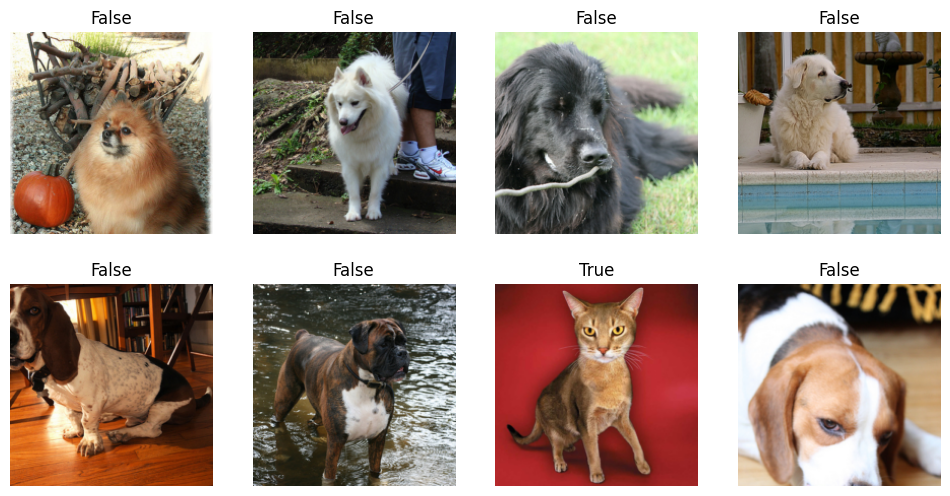

In [4]:
dls = pets.dataloaders(untar_data(URLs.PETS)/"images", bs=8) #Ici, entrée = liste de paths
dls.show_batch()
print(dls.one_batch()[0].shape)

torch.Size([8, 3, 200, 200])


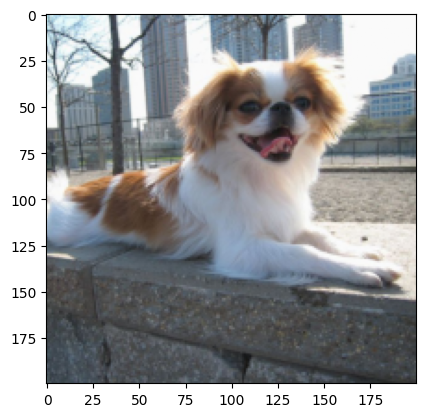

In [23]:
import matplotlib.pyplot as plt
batch1 = dls.one_batch()[0]
print(batch1.shape)
b = batch1[0]
plt.imshow(b.cpu().permute(1,2,0))


In [13]:
from scores_utils import compute_fft_scores

scores_dict = compute_fft_scores(dls.items[:50])
print(scores_dict)

Calcul des scores FFT:   0%|          | 0/50 [00:00<?, ?it/s]

{'english_setter_82.jpg': 0.6263810992240906, 'Birman_98.jpg': 0.35238105058670044, 'scottish_terrier_41.jpg': 0.49272266030311584, 'japanese_chin_19.jpg': 0.4036268889904022, 'chihuahua_67.jpg': 0.4208945035934448, 'havanese_131.jpg': 0.4687945544719696, 'British_Shorthair_182.jpg': 0.444646418094635, 'pug_118.jpg': 0.5755817890167236, 'Bombay_68.jpg': 0.4508773386478424, 'saint_bernard_80.jpg': 0.5268968939781189, 'scottish_terrier_27.jpg': 0.5169936418533325, 'leonberger_104.jpg': 0.6453014016151428, 'american_bulldog_203.jpg': 0.5983067154884338, 'Maine_Coon_133.jpg': 0.5185381174087524, 'basset_hound_16.jpg': 0.4198974668979645, 'keeshond_165.jpg': 0.5535324811935425, 'basset_hound_64.jpg': 0.509293258190155, 'scottish_terrier_117.jpg': 0.44532284140586853, 'Abyssinian_119.jpg': 0.43001773953437805, 'great_pyrenees_176.jpg': 0.5133951902389526, 'leonberger_85.jpg': 0.5228133797645569, 'basset_hound_42.jpg': 0.4159229099750519, 'beagle_42.jpg': 0.5755136013031006, 'american_pit_bul